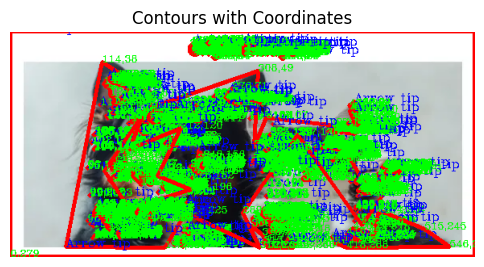

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

font = cv2.FONT_HERSHEY_COMPLEX

# Load images
img2 = cv2.imread("blur1.webp", cv2.IMREAD_COLOR)
img = cv2.imread("blur1.webp", cv2.IMREAD_GRAYSCALE)

# Check if image loaded
if img is None or img2 is None:
    print("Error: Image not found. Check file path.")
else:

    # Binarize image
    _, threshold = cv2.threshold(img, 110, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        approx = cv2.approxPolyDP(cnt, 0.009 * cv2.arcLength(cnt, True), True)

        # Draw contour
        cv2.drawContours(img2, [approx], 0, (0, 0, 255), 3)

        # Flatten contour points
        n = approx.ravel()
        i = 0

        while i < len(n):
            x = n[i]
            y = n[i+1]

            if i == 0:
                cv2.putText(img2, "Arrow tip", (x, y), font, 0.5, (255, 0, 0), 1)
            else:
                text = str(x) + "," + str(y)
                cv2.putText(img2, text, (x, y), font, 0.4, (0, 255, 0), 1)

            i = i + 2

    # Convert BGR to RGB for display
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # Display using matplotlib
    plt.figure(figsize=(6,6))
    plt.imshow(img2_rgb)
    plt.title("Contours with Coordinates")
    plt.axis("off")
    plt.show()